RESULTS (%)
           model_mean  model_std  baseline_mean  baseline_std
accuracy        97.89       1.42          62.74          0.39
recall          95.76       3.36           0.00          0.00
precision       98.56       1.51           0.00          0.00
f1              97.11       1.98           0.00          0.00

CLINICAL RESULTS
average false negatives per fold: 1.8
total false negatives across repeated validation: 90
malignant miss rate: 4.25 %


/tmp/ipykernel_640/3904753754.py:202: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


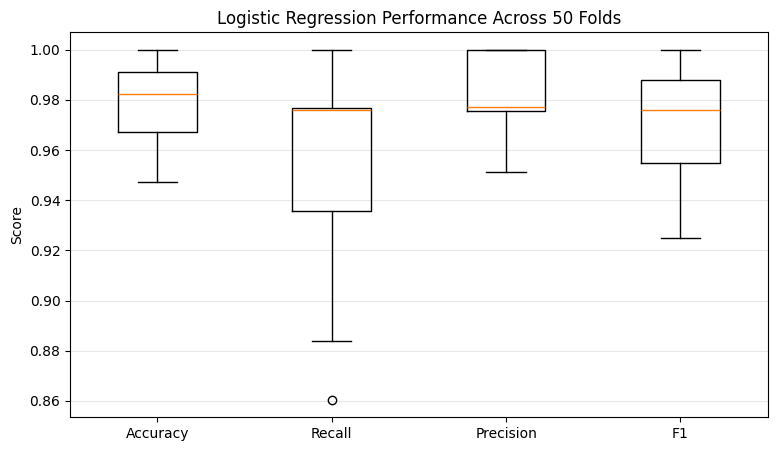

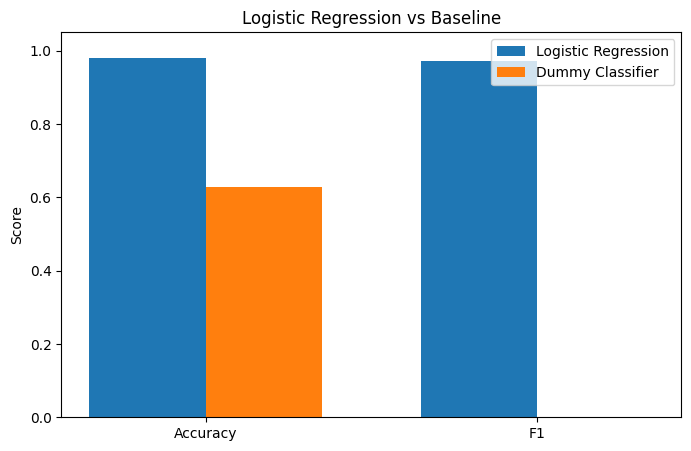

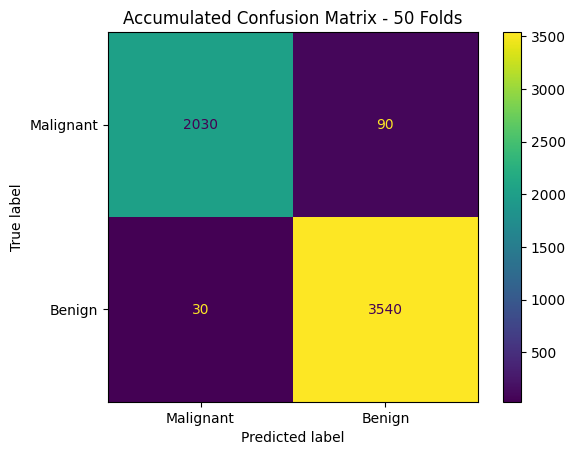

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.base import clone


# load data
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="diagnosis"
)

# 1 = benign
# 0 = malignant


# repeated stratified validation
rskf = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)


# logistic regression pipeline
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])


# baseline pipeline
baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", DummyClassifier(strategy="prior"))
])


# malignant is label 0, so pos_label must be changed
scoring = {
    "accuracy": "accuracy",

    "recall": make_scorer(
        recall_score,
        pos_label=0
    ),

    "precision": make_scorer(
        precision_score,
        pos_label=0,
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        pos_label=0,
        zero_division=0
    )
}


# evaluate logistic regression
model_results = cross_validate(
    model,
    X,
    y,
    cv=rskf,
    scoring=scoring
)


# evaluate baseline
baseline_results = cross_validate(
    baseline,
    X,
    y,
    cv=rskf,
    scoring=scoring
)


# create summary table
metrics = ["accuracy", "recall", "precision", "f1"]

summary = pd.DataFrame({
    "model_mean": [
        model_results[f"test_{metric}"].mean()
        for metric in metrics
    ],

    "model_std": [
        model_results[f"test_{metric}"].std()
        for metric in metrics
    ],

    "baseline_mean": [
        baseline_results[f"test_{metric}"].mean()
        for metric in metrics
    ],

    "baseline_std": [
        baseline_results[f"test_{metric}"].std()
        for metric in metrics
    ]
}, index=metrics)


print("RESULTS (%)")
print((summary * 100).round(2))


# calculate false negatives for every fold
false_negatives = []
confusion_matrices = []

for train_index, test_index in rskf.split(X, y):

    fold_model = clone(model)

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    fold_model.fit(X_train, y_train)

    predictions = fold_model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    )

    confusion_matrices.append(cm)

    # actual malignant = 0
    # predicted benign = 1
    false_negatives.append(cm[0, 1])


total_cm = np.sum(confusion_matrices, axis=0)

total_malignant = total_cm[0].sum()
total_false_negatives = total_cm[0, 1]

miss_rate = (
    total_false_negatives /
    total_malignant
)


print()
print("CLINICAL RESULTS")

print(
    "average false negatives per fold:",
    round(np.mean(false_negatives), 2)
)

print(
    "total false negatives across repeated validation:",
    total_false_negatives
)

print(
    "malignant miss rate:",
    round(miss_rate * 100, 2),
    "%"
)


# graph 1: model stability
plt.figure(figsize=(9, 5))

plt.boxplot([
    model_results["test_accuracy"],
    model_results["test_recall"],
    model_results["test_precision"],
    model_results["test_f1"]
], labels=[
    "Accuracy",
    "Recall",
    "Precision",
    "F1"
])

plt.ylabel("Score")
plt.title("Logistic Regression Performance Across 50 Folds")
plt.grid(axis="y", alpha=0.3)
plt.show()


# graph 2: model vs baseline
model_scores = [
    model_results["test_accuracy"].mean(),
    model_results["test_f1"].mean()
]

baseline_scores = [
    baseline_results["test_accuracy"].mean(),
    baseline_results["test_f1"].mean()
]

x = np.arange(2)
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    model_scores,
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width / 2,
    baseline_scores,
    width,
    label="Dummy Classifier"
)

plt.xticks(
    x,
    ["Accuracy", "F1"]
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Logistic Regression vs Baseline")
plt.legend()
plt.show()


# graph 3: accumulated confusion matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=total_cm,
    display_labels=["Malignant", "Benign"]
)

display.plot(
    values_format="d"
)

plt.title(
    "Accumulated Confusion Matrix - 50 Folds"
)

plt.show()


## 1. Defensa contra la Crítica 1: El Espejismo de la Exactitud

El análisis confirma que utilizar únicamente **Accuracy** no es suficiente para evaluar un modelo destinado al diagnóstico temprano de cáncer.

La Regresión Logística obtuvo un Accuracy promedio de aproximadamente **97.89%**. Sin embargo, la métrica clínicamente más relevante es el **Recall para la clase maligna**, debido a que mide qué proporción de los tumores malignos reales logra identificar correctamente el sistema.

El modelo obtuvo:

* **Recall para malignidad: 95.76%**
* **Precision para malignidad: 98.56%**
* **F1-score para malignidad: 97.11%**

Un Recall de 95.76% significa que aproximadamente **95.76 de cada 100 casos malignos son identificados correctamente**, mientras que aproximadamente **4.24% son clasificados incorrectamente como benignos**.

Estos últimos corresponden a los errores clínicamente más preocupantes: pacientes que realmente presentan un tumor maligno pero cuyo resultado generado por el modelo sería benigno.

Durante las 50 evaluaciones realizadas mediante validación cruzada repetida, se observaron aproximadamente **1.8 falsos negativos por fold en promedio**.

Por esta razón, el Recall es una métrica crítica en este escenario. Un falso negativo puede retrasar estudios adicionales, seguimiento o tratamiento médico, por lo que conocer la sensibilidad del sistema proporciona información clínica que el Accuracy por sí solo oculta.

Por lo tanto, el 97.89% de Accuracy no debe interpretarse aisladamente. La evidencia relevante es que el sistema presenta una sensibilidad para malignidad de aproximadamente **95.76%**.

---

## 2. Defensa contra la Crítica 2: La sospecha de suerte y la semilla aleatoria

Para comprobar que el resultado no depende únicamente de una partición aleatoria favorable, el modelo fue evaluado utilizando **Repeated Stratified K-Fold** con:

* 5 folds.
* 10 repeticiones.
* 50 evaluaciones en total.
* `random_state=42` para garantizar reproducibilidad.

Además, la estratificación conserva aproximadamente la misma proporción de casos benignos y malignos dentro de cada fold.

El resultado promedio del modelo fue:

* **Accuracy: 97.89% ± 1.42%**
* **Recall maligno: 95.76% ± 3.36%**
* **Precision maligno: 98.56% ± 1.51%**
* **F1 maligno: 97.11% ± 1.98%**

La desviación estándar permite observar cuánto cambia el rendimiento cuando el modelo recibe diferentes subconjuntos de pacientes.

Por ejemplo, una desviación estándar de aproximadamente **1.42 puntos porcentuales en Accuracy** indica que los resultados de las distintas evaluaciones se mantienen relativamente cerca del promedio de 97.89%.

Por lo tanto, el buen rendimiento no aparece únicamente en una división específica generada por una semilla afortunada. El modelo mantiene un desempeño elevado a través de **50 conjuntos de entrenamiento y prueba diferentes**.

La mayor variabilidad aparece en el Recall maligno, con una desviación estándar de aproximadamente 3.36 puntos porcentuales. Esto también es razonable debido al tamaño reducido del dataset y al menor número de casos malignos disponibles en cada fold.

La evidencia permite concluir que el comportamiento del modelo es relativamente estable y reproducible.

---

## 3. Defensa contra la Crítica 3: La Trampa de la Clase Mayoritaria

Para comprobar que el modelo realmente aprende información útil, se construyó un `DummyClassifier` utilizando la estrategia `prior`.

Este modelo representa una regla extremadamente sencilla: utilizar únicamente la distribución de las clases y favorecer la clase mayoritaria, que en este dataset corresponde a los pacientes benignos.

El baseline obtuvo aproximadamente:

* **Accuracy: 62.74%**
* **Recall maligno: 0%**
* **F1 maligno: 0%**

La Regresión Logística obtuvo:

* **Accuracy: 97.89%**
* **Recall maligno: 95.76%**
* **F1 maligno: 97.11%**

La diferencia de Accuracy es de aproximadamente:

**97.89% − 62.74% = 35.15 puntos porcentuales.**

El baseline puede obtener alrededor de 63% de Accuracy simplemente porque la mayoría de los registros son benignos. Sin embargo, al predecir sistemáticamente la clase mayoritaria, no identifica correctamente ningún tumor maligno, obteniendo un Recall y un F1 para malignidad iguales a cero.

La Regresión Logística, en cambio, consigue identificar aproximadamente **95.76% de los tumores malignos reales**.

Además, la reducción relativa del error de clasificación frente al baseline es de aproximadamente **94.3%**.

Por lo tanto, existe evidencia matemática clara de que el modelo aporta capacidad predictiva adicional y no está obteniendo un buen resultado simplemente por aprovechar el desequilibrio natural de las clases.

---

## 4. Defensa contra la Crítica 4: Fuga de Información

El protocolo utiliza la clase `Pipeline` de Scikit-Learn para encapsular las etapas de:

1. Imputación mediante `SimpleImputer`.
2. Estandarización mediante `StandardScaler`.
3. Entrenamiento mediante `LogisticRegression`.

Durante cada fold de la validación cruzada, Scikit-Learn separa primero los datos de entrenamiento de los datos de prueba.

Posteriormente, el `Pipeline` ejecuta `fit()` únicamente sobre el conjunto de entrenamiento.

Esto significa que el `SimpleImputer` calcula sus valores de reemplazo utilizando exclusivamente los pacientes del conjunto de entrenamiento.

De la misma manera, el `StandardScaler` calcula la media y la desviación estándar exclusivamente utilizando las observaciones de entrenamiento.

Conceptualmente, la transformación aplicada a una variable es:

[
z = \frac{x-M}{S}
]

donde:

* (M) representa la media calculada únicamente con los datos de entrenamiento.
* (S) representa la desviación estándar calculada únicamente con los datos de entrenamiento.
* (x) corresponde al valor que se desea transformar.

Una vez calculados estos parámetros, los mismos valores de (M) y (S) son utilizados para transformar el conjunto de prueba.

El conjunto de prueba nunca participa en el cálculo de estos parámetros.

El flujo correcto dentro de cada fold es:

**Training fold → calcular mediana, media y desviación estándar → entrenar modelo**

y posteriormente:

**Test fold → utilizar los parámetros aprendidos del training fold → realizar predicciones**

Esto evita que información estadística proveniente de los pacientes utilizados para evaluar el sistema influya en el entrenamiento.

Aunque el dataset Breast Cancer Wisconsin utilizado en este experimento no contiene valores nulos que requieran realmente imputación, mantener `SimpleImputer` dentro del `Pipeline` garantiza que el procedimiento continuaría siendo seguro si aparecieran datos faltantes en un conjunto de datos futuro.

Por lo tanto, el uso del `Pipeline` proporciona un protocolo de evaluación protegido contra fuga de información durante la imputación, estandarización y entrenamiento.

---

# Conclusión

Las cuatro pruebas realizadas indican que el resultado inicial no depende únicamente de un Accuracy elevado.

La Regresión Logística:

* Mantiene aproximadamente **97.89% de Accuracy** durante 50 evaluaciones.
* Detecta aproximadamente **95.76% de los tumores malignos**.
* Presenta aproximadamente **1.8 falsos negativos por fold**.
* Mantiene desviaciones estándar relativamente bajas.
* Supera ampliamente el baseline de 62.74%.
* Obtiene un F1 maligno de aproximadamente **97.11% frente a 0% del baseline**.
* Utiliza un Pipeline que evita que los datos de prueba participen en la imputación o estandarización.

En consecuencia, existe evidencia cuantitativa de que el modelo aprende patrones predictivos reales, mantiene un rendimiento relativamente estable y utiliza un procedimiento de validación técnicamente protegido contra fuga de información.

Esto no implica que el modelo deba utilizarse como sustituto de un diagnóstico médico. Los resultados justifican su desempeño experimental como sistema de apoyo, mientras que un despliegue clínico real requeriría validación externa, evaluación prospectiva y análisis adicional de riesgos clínicos.
